In [1]:
# %matplotlib qt

In [2]:
from __future__ import annotations

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (нужно для 3D)

from maneuvering.types import Scalar
from maneuvering.orbit.keplerian import Kep, KepTrue
from maneuvering.utils.math_tools import normalize, normalize_angle, solve_acos_bsin_c_eq_0
from maneuvering.orbit.convert_kep_cart import convert_kep_true_to_cart
from maneuvering.utils.normal_vector import normal_vector
from maneuvering.utils.periapsis_vector import periapsis_vector

In [3]:
deg = math.pi / 180.0
mu = 3.9860044158e14

In [4]:
def p(a: float, e: float) -> float:
    return a * (1.0 - e * e)

In [5]:
def a_coef(o1: Kep, o2: Kep) -> float:
    p1 = p(o1.a, o1.e)
    p2 = p(o2.a, o2.e)
    dw = o2.w - o1.w
    return o2.e * p1 * math.cos(dw) - o1.e * p2

In [6]:
def b_coef(o1: Kep, o2: Kep) -> float:
    p1 = p(o1.a, o1.e)
    dw = o2.w - o1.w
    return o2.e * p1 * math.sin(dw)

In [7]:
def c_coef(o1: Kep, o2: Kep) -> float:
    return p(o1.a, o1.e) - p(o2.a, o2.e)

### Компланарный одноимпульсный переход
Example 2.1 Single-Impulse Coplanar Transfer

In [8]:
o1 = Kep(a=10000e3, e=0.1, w=20*deg, i=0*deg, raan=0*deg)
o2 = Kep(a=12000e3, e=0.35, w=90*deg, i=0*deg, raan=0*deg)

In [9]:
nu1_arr = solve_acos_bsin_c_eq_0(a_coef(o1, o2), b_coef(o1, o2), c_coef(o1, o2))
nu2_arr = [normalize_angle(nu1 - (o2.w - o1.w)) for nu1 in nu1_arr]
for nu1, nu2 in zip(nu1_arr, nu2_arr):
    print(f"nu1 = {nu1 / deg} deg, nu2 = {nu2 / deg} deg")

nu1 = 8.82379742388592 deg, nu2 = 298.82379742388594 deg
nu1 = 166.5296847188247 deg, nu2 = 96.52968471882471 deg


Первая точка пересечения

In [10]:
pos11 = KepTrue(a=10000e3, e=0.1, w=20*deg, i=0*deg, raan=0*deg, nu=nu1_arr[0])
pos21 = KepTrue(a=12000e3, e=0.35, w=90*deg, i=0*deg, raan=0*deg, nu=nu2_arr[0])

In [11]:
pos11_rv = convert_kep_true_to_cart(pos11, mu)
pos21_rv = convert_kep_true_to_cart(pos21, mu)
print(pos11_rv)
print(pos21_rv)
np.testing.assert_allclose(pos11_rv.r, pos21_rv.r, rtol=0, atol=1e-4)

Cart(r=array([7893451.41355674, 4343731.96423652,       0.        ]), v=array([-3276.19629407,  6155.40948053,     0.        ]))
Cart(r=array([7893451.41355674, 4343731.96423652,       0.        ]), v=array([-5119.63984404,  5390.28353527,     0.        ]))


In [12]:
dv1 = pos21_rv.v - pos11_rv.v 
print(dv1)
print(np.linalg.norm(dv1))

[-1843.44354997  -765.12594526     0.        ]
1995.9212995586947


Вторая точка пересечения

In [13]:
pos12 = KepTrue(a=10000e3, e=0.1, w=20*deg, i=0*deg, raan=0*deg, nu=nu1_arr[1])
pos22 = KepTrue(a=12000e3, e=0.35, w=90*deg, i=0*deg, raan=0*deg, nu=nu2_arr[1])

In [14]:
pos12_rv = convert_kep_true_to_cart(pos12, mu)
pos22_rv = convert_kep_true_to_cart(pos22, mu)
print(pos12_rv)
print(pos22_rv)
np.testing.assert_allclose(pos12_rv.r, pos22_rv.r, rtol=0, atol=1e-4)

Cart(r=array([-10895341.25985329,  -1247085.78318032,        -0.        ]), v=array([  504.55154674, -5707.86391034,    -0.        ]))
Cart(r=array([-10895341.25985329,  -1247085.78318032,        -0.        ]), v=array([-1453.73553409, -6112.6325239 ,     0.        ]))


In [15]:
dv2 = pos22_rv.v - pos12_rv.v 
print(dv2)
print(np.linalg.norm(dv2))

[-1958.28708083  -404.76861356     0.        ]
1999.6814549970968


### Некомпланарный одноимпульсный переход
Example 2.2 Orbit Transfer at the Intersection of the Planes

In [16]:
o1 = Kep(a=18654.3640e3, e=0.28969592, w=265.55428*deg, i=35.62718*deg, raan=89.44357*deg)
o2 = Kep(a=20679.0085e3, e=0.16932267, w=234.60634*deg, i=38.46693*deg, raan=107.25881*deg)

In [17]:
h1 = normal_vector(o1.i, o1.raan)
h2 = normal_vector(o2.i, o2.raan)
print(h1)
print(h2)

[ 0.58248115 -0.00565696  0.81282452]
[0.59405403 0.18455884 0.78296733]


In [18]:
I = normalize(np.cross(h1, h2))
print(I)

[-0.80442056  0.13957782  0.57743017]


In [19]:
p1 = periapsis_vector(o1)
p2 = periapsis_vector(o2)
print(p1)
print(p2)

[ 0.80958792 -0.08538086 -0.58075598]
[ 0.7813694  -0.36374561 -0.50710057]


In [20]:
def directed_angle(a: np.ndarray, b: np.ndarray, h: np.ndarray) -> float:
    """Угол от a к b по движению вокруг нормали h, в диапазоне [0, 2π)."""
    a, b, h = normalize(a), normalize(b), normalize(h)
    return normalize_angle(np.arctan2(np.dot(h, np.cross(a, b)), np.dot(a, b)))

In [21]:
def r(a: float, e: float, nu: float) -> float:
    return p(a, e) / (1.0 + e * math.cos(nu))

Первая точка

In [22]:
nu11 = directed_angle(p1, I, h1)
nu21 = directed_angle(p2, I, h2)
print(nu11 / deg)
print(nu21 / deg)

176.87445843164463
193.55739152937653


In [23]:
r11 = r(o1.a, o1.e, nu11)
r21 = r(o2.a, o2.e, nu21)
print(r11)
print(r21)

24043870.00480024
24043869.237595744


In [24]:
pos1 = KepTrue(a=18654.3640e3, e=0.28969592, w=265.55428*deg, i=35.62718*deg, raan=89.44357*deg, nu=nu11)
pos2 = KepTrue(a=20679.0085e3, e=0.16932267, w=234.60634*deg, i=38.46693*deg, raan=107.25881*deg, nu=nu21)

In [25]:
pos1_rv = convert_kep_true_to_cart(pos1, mu)
pos2_rv = convert_kep_true_to_cart(pos2, mu)
print(pos1_rv)
print(pos2_rv)

Cart(r=array([-19341383.29548689,   3355990.90081272,  13883655.9341715 ]), v=array([ -462.01211884, -3388.27473122,   307.50302998]))
Cart(r=array([-19341382.67833183,   3355990.79372798,  13883655.49116448]), v=array([  132.1330072 , -3645.13356918,   758.96840333]))


In [26]:
dv = pos2_rv.v - pos1_rv.v
print(dv)
print(np.linalg.norm(dv))

[ 594.14512605 -256.85883796  451.46537334]
789.1805096264409


Вторая точка

In [27]:
nu12 = directed_angle(p1, -I, h1)
nu22 = directed_angle(p2, -I, h2)
print(nu12 / deg)
print(nu22 / deg)

356.87445843164465
13.557391529376549


In [28]:
r12 = r(o1.a, o1.e, nu12)
r22 = r(o2.a, o2.e, nu22)
print(r12)
print(r22)

13254699.725036083
17247173.82146143


### Коррекция большой полуоси и эксцентриситета

In [29]:
def solve_true_anomaly(r: float, a: float, e: float, tol: float = 1e-12) -> list[float]:
    """Два решения ν2 в [0, 2π), либо [] при недостижимом радиусе.

    В апсиде оба варианта совпадают. Круговую целевую орбиту
    рассматриваем отдельно, поскольку её перицентр не определён.
    """
    if r <= 0 or a <= 0 or not 0 <= e < 1:
        raise ValueError("Require r > 0, a > 0 and 0 <= e < 1.")
    if e < tol:
        raise ValueError("True anomaly is undefined for a circular target orbit.")
    c = (a * (1.0 - e * e) / r - 1.0) / e
    if abs(c) > 1.0 + tol:
        return []
    alpha = math.acos(max(-1.0, min(1.0, c)))
    return [alpha, normalize_angle(2.0 * math.pi - alpha)]

In [30]:
pos1 = KepTrue(a=26_000e3, e=0.6, w=250*deg, i=64*deg, raan=0*deg, nu=60*deg)
a2 = 26_554e3
e2 = 0.7

In [31]:
u = pos1.w + pos1.nu
dist = r(pos1.a, pos1.e, pos1.nu)
nu1, nu2 = solve_true_anomaly(dist, a2, e2)
nu1 = normalize_angle(nu1)
nu2 = normalize_angle(nu2)
w1 = normalize_angle(u - nu1)
w2 = normalize_angle(u - nu2)
print(f"w1 = {w1 / deg}, w2 = {w2 / deg}")
print(f"nu1 = {nu1 / deg}, nu2 = {nu2 / deg}")

w1 = 224.75371179339268, w2 = 35.24628820660733
nu1 = 85.2462882066073, nu2 = 274.75371179339265


In [32]:
pos21 = KepTrue(a=a2, e=e2, w=w1, i=pos1.i, raan=pos1.raan, nu=nu1)
pos22 = KepTrue(a=a2, e=e2, w=w2, i=pos1.i, raan=pos1.raan, nu=nu2)

In [33]:
pos1_rv = convert_kep_true_to_cart(pos1, mu)
pos21_rv = convert_kep_true_to_cart(pos21, mu)
pos22_rv = convert_kep_true_to_cart(pos22, mu)
print(pos1_rv)
print(pos21_rv)
print(pos22_rv)
np.testing.assert_allclose(pos1_rv.r, pos21_rv.r, rtol=0, atol=1e-4)

np.testing.assert_allclose(pos1_rv.r, pos22_rv.r, rtol=0, atol=1e-4)

Cart(r=array([ 8227681.4039877 , -4298390.79707477, -8813007.1638515 ]), v=array([6508.75846053,  938.83054181, 1924.88786646]))
Cart(r=array([ 8227681.4039877 , -4298390.79707477, -8813007.1638515 ]), v=array([6829.76180413,  346.48932102,  710.40838595]))
Cart(r=array([ 8227681.4039877 , -4298390.79707477, -8813007.1638515 ]), v=array([1964.36946134, 2888.31813567, 5921.92976926]))


In [34]:
dv1 = pos21_rv.v - pos1_rv.v
dv2 = pos22_rv.v - pos1_rv.v
print(dv1)
print(np.linalg.norm(dv1))
print(dv2)
print(np.linalg.norm(dv2))

[  321.00334359  -592.34122079 -1214.47948051]
1388.838247251175
[-4544.38899919  1949.48759386  3997.0419028 ]
6358.326605902053


### Оптимизация коррекции большой полуоси и эксцентриситета

In [35]:
def a_e_dV(o1: KepTrue, a2: float, e2: float, mu: float):
    u = normalize_angle(o1.w + o1.nu)
    dist = r(o1.a, o1.e, o1.nu)
    anomalies = solve_true_anomaly(dist, a2, e2)
    if not anomalies:
        return math.nan, math.nan
    s1 = convert_kep_true_to_cart(o1, mu)
    values = []
    for nu2 in anomalies:
        o2 = KepTrue(a=a2, e=e2, w=normalize_angle(u-nu2),
                     i=o1.i, raan=o1.raan, nu=nu2)
        s2 = convert_kep_true_to_cart(o2, mu)
        np.testing.assert_allclose(s2.r, s1.r, rtol=0, atol=1e-4)
        values.append(float(np.linalg.norm(s2.v-s1.v)))
    return tuple(values)

In [36]:
a1, e1, i1, raan1, w1 = 26_000e3, 0.6, 64*deg, 0.0*deg, 250*deg
a2, e2 = 26_554e3, 0.7

N = 720  # число точек по истинной аномалии
nus = np.linspace(0.0, 2.0*math.pi, N, endpoint=False)

xs_deg = np.rad2deg(nus)
dvA = np.empty(N)
dvB = np.empty(N)

for k, nu in enumerate(nus):
    o1 = KepTrue(a=a1, e=e1, i=i1, raan=raan1, w=w1, nu=nu)
    d1, d2 = a_e_dV(o1, a2, e2, mu)
    dvA[k] = d1
    dvB[k] = d2

In [37]:
tick_params_font_size = 18
label_font_size = 22

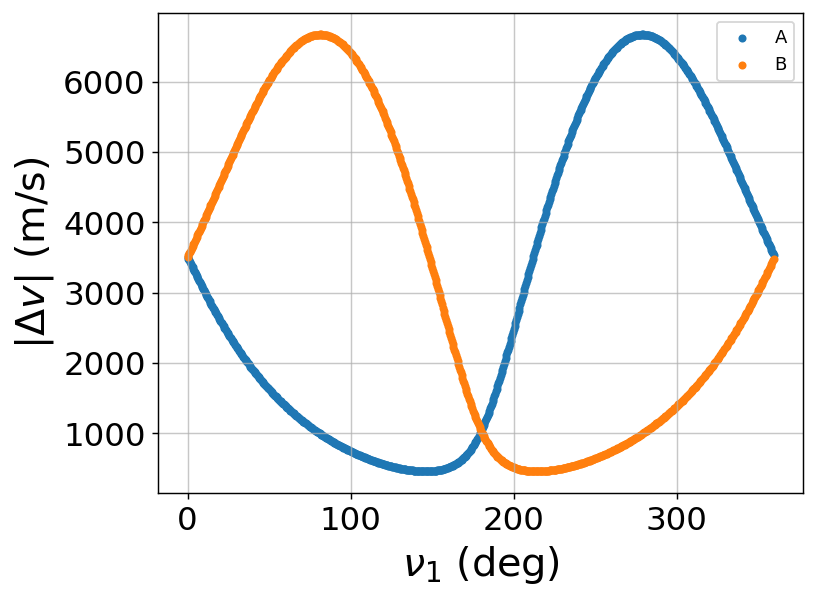

In [38]:
fig, ax = plt.subplots()
ax.scatter(xs_deg, dvA, s=12, label="A")
ax.scatter(xs_deg, dvB, s=12, label="B")
ax.set_xlabel(r"$\nu_1$ (deg)", fontsize=label_font_size)
ax.set_ylabel(r"$\|\Delta v\|$ (m/s)", fontsize=label_font_size)
ax.grid(True, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=tick_params_font_size)
ax.legend()
plt.show()

### Коррекция большой полуоси и аргумента перицентра

In [39]:
def solve_quadratic(a: float, b: float, c: float, tol: float = 1e-15) -> list[float]:
    """
    Решает a x^2 + b x + c = 0 в действительных числах.
    Возвращает 0, 1 или 2 корня (только вещественные). Если D<0 -> [].

    Численно устойчивый вариант (Kahan):
      q = -0.5 * (b + sign(b)*sqrt(D)), затем x1 = q/a, x2 = c/q.
    """
    # Линейный (или вырожденный) случай
    if abs(a) < tol:
        if abs(b) < tol:
            return []  # либо беск. много, если |c|<tol; тут считаем, что решений нет
        return [-c / b]

    D = b*b - 4.0*a*c
    if D < 0.0:
        return []  # нет действительных решений

    sqrtD = math.sqrt(D)

    # Устойчивое вычисление
    q = -0.5 * (b + (sqrtD if b >= 0 else -sqrtD))
    x1 = q / a
    # Если q почти ноль, используем стандартную формулу для второго корня
    x2 = c / q if abs(q) > tol else (-b / (2.0*a))

    # Слить почти совпадающие корни
    if abs(x1 - x2) < tol:
        return [0.5*(x1 + x2)]
    return [x1, x2]

In [40]:
pos1 = KepTrue(a=26_222e3, e=0.7, w=266*deg, i=63.434*deg, raan=0*deg, nu=222*deg)
a2 = 26_554e3
w2 = 270*deg

In [41]:
dist = r(pos1.a, pos1.e, pos1.nu)
u = normalize_angle(pos1.w + pos1.nu)
nu2 = normalize_angle(u - w2)
print(f"nu2 = {nu2 / deg}")

nu2 = 217.99999999999997


In [42]:
e21, e22 = solve_quadratic(a2, dist * math.cos(nu2), dist - a2)
print(f"e21 = {e21}")
print(f"e22 = {e22}")

e21 = 0.7619724421730308
e22 = 0.06516786701549572


In [43]:
pos21 = KepTrue(a=a2, e=e21, w=w2, i=pos1.i, raan=pos1.raan, nu=nu2)
pos22 = KepTrue(a=a2, e=e22, w=w2, i=pos1.i, raan=pos1.raan, nu=nu2)

In [44]:
pos1_rv = convert_kep_true_to_cart(pos1, mu)
pos21_rv = convert_kep_true_to_cart(pos21, mu)
pos22_rv = convert_kep_true_to_cart(pos22, mu)
print(pos1_rv)
print(pos21_rv)
print(pos22_rv)
np.testing.assert_allclose(pos1_rv.r, pos21_rv.r, rtol=0, atol=1e-4)

np.testing.assert_allclose(pos1_rv.r, pos22_rv.r, rtol=0, atol=1e-4)

Cart(r=array([-17160066.69191526,   9822872.75508522,  19644932.19911726]), v=array([ -489.80182678, -1622.44275447, -3244.75117445]))
Cart(r=array([-17160066.69191527,   9822872.75508522,  19644932.19911727]), v=array([ -155.77707798, -1647.25978589, -3294.3831825 ]))
Cart(r=array([-17160066.69191526,   9822872.75508521,  19644932.19911726]), v=array([-2806.54480275, -1069.05347157, -2138.01842799]))


In [45]:
dv1 = pos21_rv.v - pos1_rv.v
dv2 = pos22_rv.v - pos1_rv.v
print(dv1)
print(np.linalg.norm(dv1))
print(dv2)
print(np.linalg.norm(dv2))

[334.0247488  -24.81703142 -49.63200804]
338.6026492492687
[-2316.74297598   553.3892829   1106.73274646]
2626.4795996279677


### Оптимизация коррекции большой полуоси и аргумента перицентра

In [46]:
def a_w_dV(o1: KepTrue, a2: float, w2: float, mu: float, tol: float = 1e-12):
    dist = r(o1.a, o1.e, o1.nu)
    nu2 = normalize_angle(o1.w + o1.nu - w2)
    # A — больший корень, B — меньший. Не меняем их местами при фильтрации.
    roots = sorted(solve_quadratic(a2, dist * math.cos(nu2), dist - a2), reverse=True)
    s1 = convert_kep_true_to_cart(o1, mu)
    dv_vals = [math.nan, math.nan]
    for idx, e2 in enumerate(roots):
        if not tol < e2 < 1.0-tol:
            continue
        o2 = KepTrue(a=a2, e=e2, i=o1.i, raan=o1.raan, w=w2, nu=nu2)
        s2 = convert_kep_true_to_cart(o2, mu)
        np.testing.assert_allclose(s2.r, s1.r, rtol=0, atol=1e-3)
        dv_vals[idx] = float(np.linalg.norm(s2.v-s1.v))
    return tuple(dv_vals)

In [47]:
a1, e1, i1, raan1, w1 = 26_222e3, 0.7, 63.434 * deg, 0.0 * deg, 266 * deg
a2, w2 = 26_554e3, 270*deg

N = 720  # число точек по истинной аномалии
nus = np.linspace(0.0, 2.0 * math.pi, N, endpoint=False)

xs_deg = np.rad2deg(nus)
dvA = np.empty(N)
dvB = np.empty(N)

for k, nu in enumerate(nus):
    o1 = KepTrue(a=a1, e=e1, i=i1, raan=raan1, w=w1, nu=nu)
    d1, d2 = a_w_dV(o1, a2, w2, mu)
    dvA[k], dvB[k] = d1, d2

In [48]:
tick_params_font_size = 18
label_font_size = 22

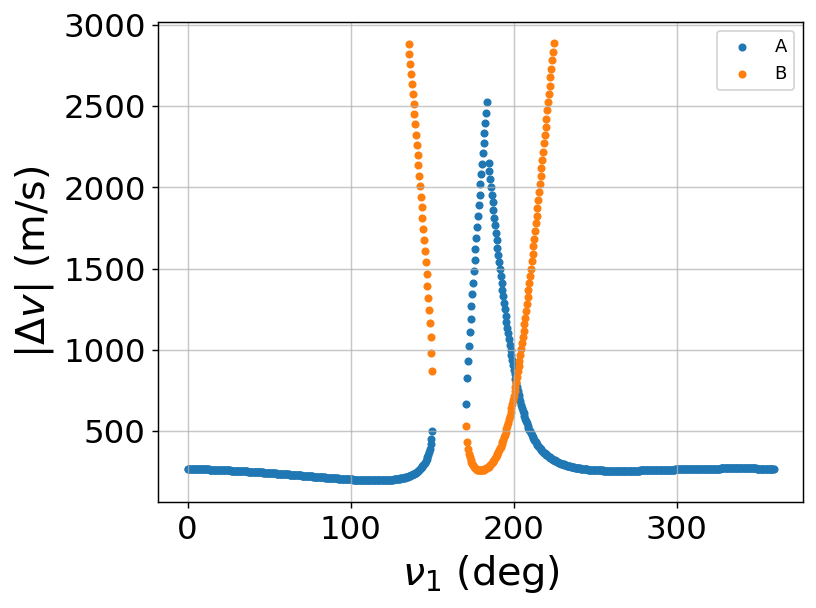

In [49]:
fig, ax = plt.subplots()
ax.scatter(xs_deg, dvA, s=12, label="A")
ax.scatter(xs_deg, dvB, s=12, label="B")
ax.set_xlabel(r"$\nu_1$ (deg)", fontsize=label_font_size)
ax.set_ylabel(r"$\|\Delta v\|$ (m/s)", fontsize=label_font_size)
ax.grid(True, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=tick_params_font_size)
ax.legend()
plt.show()

### Коррекция большой полуоси, эксцентриситета, долготы восходящего узла

In [50]:
def a_e_raan_solutions(o1: KepTrue, a2: float, e2: float, raan2: float, mu: float):
    """Конечные орбиты в той же точке; [None, None], если решения нет."""
    s1 = convert_kep_true_to_cart(o1, mu)
    dist = float(np.linalg.norm(s1.r))
    anomalies = solve_true_anomaly(dist, a2, e2)
    if not anomalies:
        return [None, None]

    rx, ry, rz = s1.r
    A = rx * math.sin(raan2) - ry * math.cos(raan2)
    # Наклонение лежит в [0, π], а не в [0, 2π).
    i2 = float(np.arctan2(-rz, A) % math.pi)
    if abs(math.sin(i2)) < 1e-12:
        # У экваториальной орбиты долгота восходящего узла не определена.
        return [None, None]

    h2 = normal_vector(i2, raan2)
    N2 = np.array([math.cos(raan2), math.sin(raan2), 0.0])
    T2 = np.cross(h2, N2)
    # После смены плоскости u2 нужно пересчитать: прежний u1 задаёт другую точку.
    u2 = normalize_angle(np.arctan2(np.dot(s1.r, T2), np.dot(s1.r, N2)))
    solutions = []
    for nu2 in anomalies:
        o2 = KepTrue(a=a2, e=e2, w=normalize_angle(u2-nu2),
                     i=i2, raan=raan2, nu=nu2)
        s2 = convert_kep_true_to_cart(o2, mu)
        np.testing.assert_allclose(s2.r, s1.r, rtol=0, atol=1e-4)
        solutions.append(o2)
    return solutions


def a_e_raan_dV(o1: KepTrue, a2: float, e2: float, raan2: float, mu: float):
    s1 = convert_kep_true_to_cart(o1, mu)
    values = []
    for o2 in a_e_raan_solutions(o1, a2, e2, raan2, mu):
        if o2 is None:
            values.append(math.nan)
        else:
            s2 = convert_kep_true_to_cart(o2, mu)
            values.append(float(np.linalg.norm(s2.v-s1.v)))
    return tuple(values)

In [51]:
a1, e1, i1, raan1, w1 = 26_000e3, 0.6, 64 * deg, 0.0 * deg, 250 * deg
a2, e2, raan2 = 26_554e3, 0.7, 3.0*deg

N = 720  # число точек по истинной аномалии
nus = np.linspace(0.0, 2.0 * math.pi, N, endpoint=False)

xs_deg = np.rad2deg(nus)
dvA = np.empty(N)
dvB = np.empty(N)

for k, nu in enumerate(nus):
    o1 = KepTrue(a=a1, e=e1, i=i1, raan=raan1, w=w1, nu=nu)
    d1, d2 = a_e_raan_dV(o1, a2, e2, raan2, mu)
    dvA[k] = d1
    dvB[k] = d2

In [52]:
tick_params_font_size = 18
label_font_size = 22

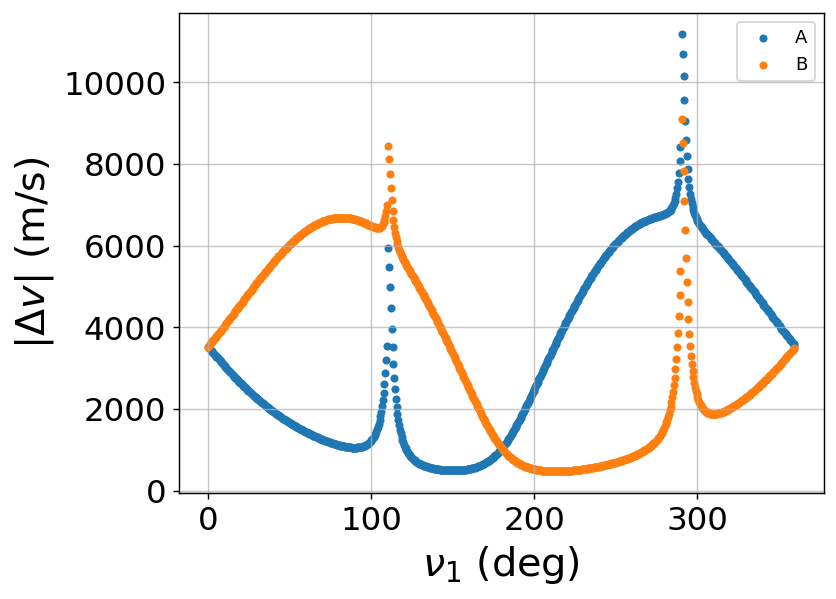

In [53]:
fig, ax = plt.subplots()
ax.scatter(xs_deg, dvA, s=12, label="A")
ax.scatter(xs_deg, dvB, s=12, label="B")
ax.set_xlabel(r"$\nu_1$ (deg)", fontsize=label_font_size)
ax.set_ylabel(r"$\|\Delta v\|$ (m/s)", fontsize=label_font_size)
ax.grid(True, alpha=0.7)
ax.tick_params(axis='both', which='major', labelsize=tick_params_font_size)
ax.legend()
plt.show()

In [54]:
# Пример при ν1 = 60°: элементы, скорости и проверка общей точки.
pos1 = KepTrue(a=26_000e3, e=0.6, i=64*deg, raan=0.0, w=250*deg, nu=60*deg)
s1 = convert_kep_true_to_cart(pos1, mu)
for label, o2 in zip(("A", "B"), a_e_raan_solutions(pos1, 26_554e3, 0.7, 3*deg, mu)):
    s2 = convert_kep_true_to_cart(o2, mu)
    print(f"{label}: i2 = {o2.i/deg:.6f}°, w2 = {o2.w/deg:.6f}°, nu2 = {o2.nu/deg:.6f}°")
    print("v2 [m/s] =", s2.v)
    print("dv [m/s] =", s2.v-s1.v)
    print(f"|dv| = {np.linalg.norm(s2.v-s1.v):.6f} m/s")
    print(f"|r2-r1| = {np.linalg.norm(s2.r-s1.r):.3e} m")

A: i2 = 61.812067°, w2 = 223.386862°, nu2 = 85.246288°
v2 [m/s] = [6821.78243445  654.21745288  552.86993673]
dv [m/s] = [  313.02397391  -284.61308893 -1372.01792973]
|dv| = 1435.765238 m/s
|r2-r1| = 6.317e-09 m
B: i2 = 61.812067°, w2 = 33.879438°, nu2 = 274.753712°
v2 [m/s] = [1956.39009166 3196.04626753 5764.39132004]
dv [m/s] = [-4552.36836887  2257.21572572  3839.50345358]
|dv| = 6368.741427 m/s
|r2-r1| = 6.317e-09 m
